<a href="https://colab.research.google.com/github/PierreCr/Digital-Pathology/blob/main/Mini_project_in_computational_pathology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-project in Computational Pathology.
# Pierre Cordier, DVM, PhD, Dipl.ECVP.
# 03/10/2026.


In [ ]:
#1. Know your computational environment.
import sys
import platform

print("Python:", sys.version)
print("Platform:", platform.platform())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)


# --
#Q1. What Python version is actually running in Colab?
#A1. Python: 3.13.15.

#Q2. Is it the same as Python 3.13.15 on your Mac?
#A2. Python 3.7.1.

#Q3. Why is it useful to record package versions in a computational pathology project?
#A3. In order to be able to reproduce the Python code and the computation.

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
NumPy: 2.1.3
pandas: 2.2.3


In [11]:
#2. Install OpenSlide.
!apt-get update
!apt-get install -y openslide-tools
!pip install openslide-python

import openslide
print("OpenSlide:", openslide.__version__)

OpenSlide: 1.4.6


In [22]:
#3. Get a small WSI (from Google Drive).
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [26]:
#4. Your first WSI object.
slide = openslide.OpenSlide("/content/drive/MyDrive/WSI_CMU-1/CMU-1.mrxs")

print(slide.dimensions)
print(slide.level_count)
print(slide.level_dimensions)
print(slide.level_downsamples)

for key, value in slide.properties.items():
  print(key, ":", value)


# --
#Q4. What are the dimensions of level 0? How many pixels is that in total?
#A4. Dimensions at level 0: (109240 x 220696). Total pixels: 24,108,831,040 (= 24.1 billion pixels or 24.1 gigapixels).

#Q5. How much larger is that than a normal 224 × 224 CNN input?
#A5. For a tile of (224 x 224), total pixels are 50,176 which is 480,485.3 times smaller.

#Q6. Look at slide.level_dimensions. Why do the dimensions become progressively smaller?
#What do you think the pyramid is used for?
#A6. The dimensions become progressively smaller due to downsampling factor being applied at each level. The pyramid structure is used for visualization at various magnification.

(109240, 220696)
10
((109240, 220696), (54620, 110348), (27310, 55174), (13655, 27587), (6827, 13793), (3413, 6896), (1706, 3448), (853, 1724), (426, 862), (213, 431))
(1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0, 512.0)


In [ ]:
#5. Understand the WSI pyramid.

#Q7. Why would you use a low-resolution level to find tissue?
#A7. It decreases computation time and there is no need for high granularity or maximum cell details for that application.

#Q8. Why wouldn't you normally use the lowest-resolution image to perform detailed nuclear classification?
#A8. Nuclear classification requires a high level of nuclear details (size, shape, chromatin aspect...).

#Q9. If level 1 has a downsample of 2 and level 3 has a downsample of 8, what does that mean?
#A9. That means that along each (x,y) axis, there are 2 times and 8 times less pixels for level 1 and level 3, respectively, compared to the level 0 reference.

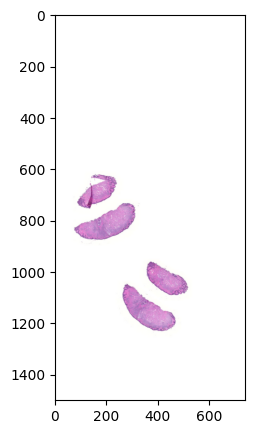

In [40]:
#6. Make your first thumbnail.
thumbnail = slide.get_thumbnail((1500, 1500))

import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.imshow(thumbnail)
plt.axis("on");
#thumbnail.save("thumbnail.png")


# --
#Q10. Does the thumbnail preserve the full-resolution image?
#A10. It doesn't, the resolution is reduced to the dimensions indicated in get_thumbnail function (a,b).

#Q11. Why is it useful for tissue detection?
#A11. Tissue detection can be faster and outlines the tissue contours (mostly based on tissue contrast compared to the white background). No need for tissue details.

#Q12. What information is lost?
#A12. Tissue details are lost due to lowest resolution.
